# Лабараторная работа №2
#### Шитова Милана ИБМ3 - 65Б
#### Данные https://www.kaggle.com/competitions/spaceship-titanic

In [79]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [145]:
data = pd.read_csv("train.csv")
data.head(10)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


In [81]:
data.shape

(8693, 14)

In [82]:
data.dtypes

PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object

In [83]:
# проверим есть ли пропущенные значения
data.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

# Обработка пропусков в данных
## Простые стратегии - удаление или заполнение нулями
Удаление колонок, содержащих пустые значения res = data.dropna(axis=1, how='any')
Удаление строк, содержащих пустые значения res = data.dropna(axis=0, how='any')


In [84]:
# Удаление колонок, содержащих пустые значения
data_new_1 = data.dropna(axis=1, how='any')
(data.shape, data_new_1.shape)

((8693, 14), (8693, 2))

In [85]:
((1460, 81), (1460, 62))
# Удаление строк, содержащих пустые значения
data_new_2 = data.dropna(axis=0, how='any')
(data.shape, data_new_2.shape)

((8693, 14), (6606, 14))

In [86]:
# проверим есть ли пропущенные значения
data_new_2.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

In [87]:
# Заполнение всех пропущенных значений нулями
# В данном случае это некорректно, так как нулями заполняются в том числе категориальные колонки
data_new_3 = data.fillna(0)
data_new_3.head(10)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,0.0,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


# "Внедрение значений" - импьютация (imputation)
## Обработка пропусков в числовых данных

In [88]:
# Выберем числовые колонки с пропущенными значениями
# Цикл по колонкам датасета
total_count = data.shape[0]
num_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and (dt=='float64' or dt=='int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка Age. Тип данных float64. Количество пустых значений 179, 2.06%.
Колонка RoomService. Тип данных float64. Количество пустых значений 181, 2.08%.
Колонка FoodCourt. Тип данных float64. Количество пустых значений 183, 2.11%.
Колонка ShoppingMall. Тип данных float64. Количество пустых значений 208, 2.39%.
Колонка Spa. Тип данных float64. Количество пустых значений 183, 2.11%.
Колонка VRDeck. Тип данных float64. Количество пустых значений 188, 2.16%.


In [89]:
# Фильтр по колонкам с пропущенными значениями
data_num = data[num_cols]
data_num

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,39.0,0.0,0.0,0.0,0.0,0.0
1,24.0,109.0,9.0,25.0,549.0,44.0
2,58.0,43.0,3576.0,0.0,6715.0,49.0
3,33.0,0.0,1283.0,371.0,3329.0,193.0
4,16.0,303.0,70.0,151.0,565.0,2.0
...,...,...,...,...,...,...
8688,41.0,0.0,6819.0,0.0,1643.0,74.0
8689,18.0,0.0,0.0,0.0,0.0,0.0
8690,26.0,0.0,0.0,1872.0,1.0,0.0
8691,32.0,0.0,1049.0,0.0,353.0,3235.0


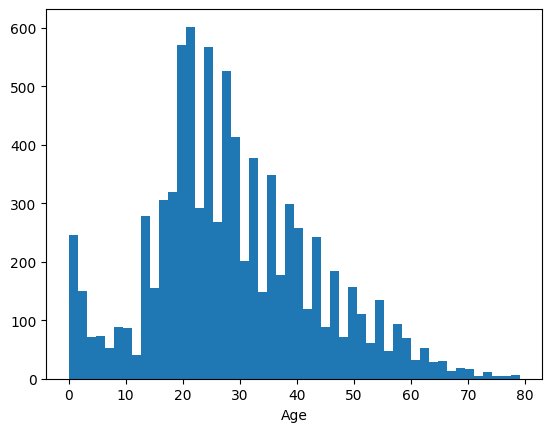

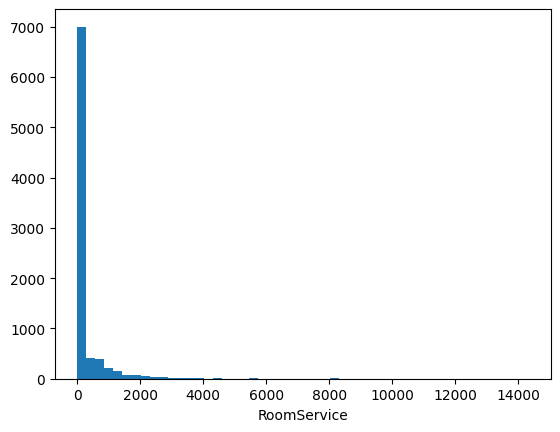

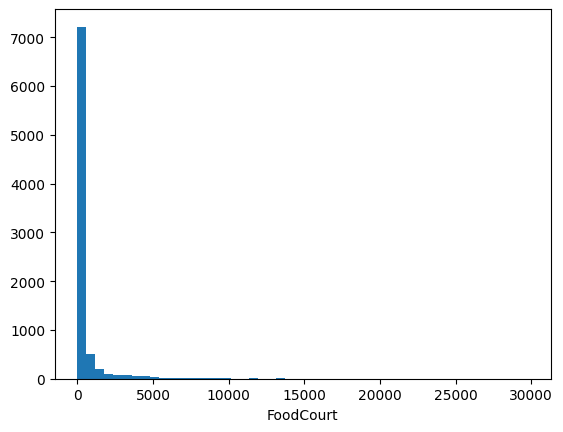

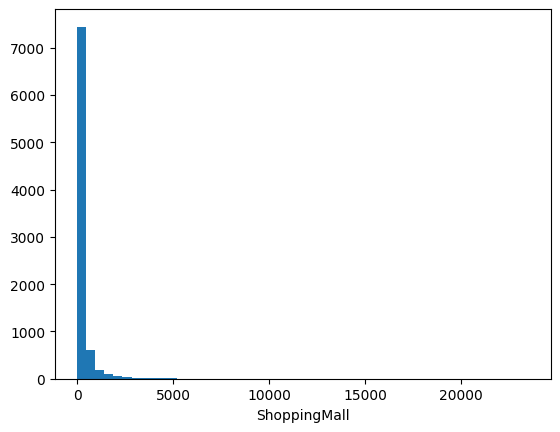

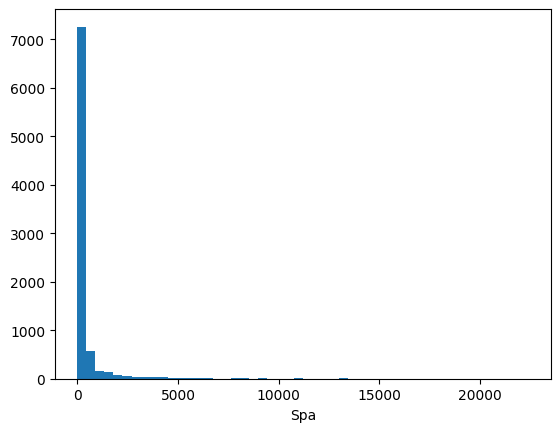

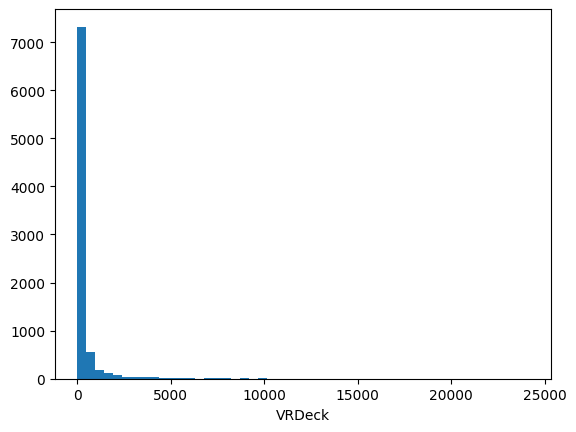

In [90]:
# Гистограмма по признакам
for col in data_num:
    plt.hist(data[col], 50)
    plt.xlabel(col)
    plt.show()

In [91]:
data_num_Age = data_num[['Age']]
data_num_Age.head()

,Age
0,39.0
1,24.0
2,58.0
3,33.0
4,16.0


In [33]:
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator

In [92]:
# Фильтр для проверки заполнения пустых значений
indicator = MissingIndicator()
mask_missing_values_only = indicator.fit_transform(data_num_Age)
mask_missing_values_only

array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]], shape=(8693, 1))

С помощью класса SimpleImputer можно проводить импьютацию различными показателями центра распределения


In [93]:
strategies=['mean', 'median', 'most_frequent']
def test_num_impute(strategy_param):
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(data_num_Age)
    return data_num_imp[mask_missing_values_only]
strategies[0], test_num_impute(strategies[0])

('mean',
 array([28.82793047, 28.82793047, 28.82793047, 28.82793047, 28.82793047,
        28.82793047, 28.82793047, 28.82793047, 28.82793047, 28.82793047,
        28.82793047, 28.82793047, 28.82793047, 28.82793047, 28.82793047,
        28.82793047, 28.82793047, 28.82793047, 28.82793047, 28.82793047,
        28.82793047, 28.82793047, 28.82793047, 28.82793047, 28.82793047,
        28.82793047, 28.82793047, 28.82793047, 28.82793047, 28.82793047,
        28.82793047, 28.82793047, 28.82793047, 28.82793047, 28.82793047,
        28.82793047, 28.82793047, 28.82793047, 28.82793047, 28.82793047,
        28.82793047, 28.82793047, 28.82793047, 28.82793047, 28.82793047,
        28.82793047, 28.82793047, 28.82793047, 28.82793047, 28.82793047,
        28.82793047, 28.82793047, 28.82793047, 28.82793047, 28.82793047,
        28.82793047, 28.82793047, 28.82793047, 28.82793047, 28.82793047,
        28.82793047, 28.82793047, 28.82793047, 28.82793047, 28.82793047,
        28.82793047, 28.82793047, 28.82793

In [94]:
strategies[1], test_num_impute(strategies[1])

('median',
 array([27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27.,
        27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27.,
        27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27.,
        27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27.,
        27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27.,
        27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27.,
        27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27.,
        27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27.,
        27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27.,
        27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27.,
        27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27.,
        27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27.,
        27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27., 27.,
        27., 27., 27., 27., 27., 27., 27

In [95]:
strategies[2], test_num_impute(strategies[2])

('most_frequent',
 array([24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24., 24.,
        24., 24., 24., 24., 24., 

Более сложная функция, которая позволяет задавать колонку и вид импьютации

In [96]:
def test_num_impute_col(dataset, column, strategy_param):
    temp_data = dataset[[column]]
    
    indicator = MissingIndicator()
    mask_missing_values_only = indicator.fit_transform(temp_data)
    
    imp_num = SimpleImputer(strategy=strategy_param)
    data_num_imp = imp_num.fit_transform(temp_data)
    
    filled_data = data_num_imp[mask_missing_values_only]
    
    return column, strategy_param, filled_data.size, filled_data[0], filled_data[filled_data.size-1]

In [97]:
data[['RoomService']].describe()

,RoomService
count,8512.000000
mean,224.687617
std,666.717663
min,0.000000
25%,0.000000
50%,0.000000
75%,47.000000
max,14327.000000


In [98]:
test_num_impute_col(data, 'RoomService', strategies[0])

('RoomService',
 'mean',
 181,
 np.float64(224.687617481203),
 np.float64(224.687617481203))

In [99]:
test_num_impute_col(data, 'RoomService', strategies[1])

('RoomService', 'median', 181, np.float64(0.0), np.float64(0.0))

In [100]:
test_num_impute_col(data, 'RoomService', strategies[2])

('RoomService', 'most_frequent', 181, np.float64(0.0), np.float64(0.0))

# Обработка пропусков в категориальных данных

In [102]:
# Выберем категориальные колонки с пропущенными значениями
# Цикл по колонкам датасета
cat_cols = []
for col in data.columns:
    # Количество пустых значений 
    temp_null_count = data[data[col].isnull()].shape[0]
    dt = str(data[col].dtype)
    if temp_null_count>0 and ((dt=='object') or (dt=='str')):
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print('Колонка {}. Тип данных {}. Количество пустых значений {}, {}%.'.format(col, dt, temp_null_count, temp_perc))

Колонка HomePlanet. Тип данных str. Количество пустых значений 201, 2.31%.
Колонка CryoSleep. Тип данных object. Количество пустых значений 217, 2.5%.
Колонка Cabin. Тип данных str. Количество пустых значений 199, 2.29%.
Колонка Destination. Тип данных str. Количество пустых значений 182, 2.09%.
Колонка VIP. Тип данных object. Количество пустых значений 203, 2.34%.
Колонка Name. Тип данных str. Количество пустых значений 200, 2.3%.


### Во всех колонках примерно одинаковое и небольшое количество пропусков, поэтому для построения модели можно использовать все признаки.

In [103]:
cat_temp_data = data[['HomePlanet']]
cat_temp_data.head()

,HomePlanet
0,Europa
1,Earth
2,Europa
3,Europa
4,Earth


In [104]:
cat_temp_data['HomePlanet'].unique()

<StringArray>
['Europa', 'Earth', 'Mars', nan]
Length: 4, dtype: str

In [105]:
cat_temp_data[cat_temp_data['HomePlanet'].isnull()].shape

(201, 1)

### Импьютация наиболее частыми значениями

In [107]:
most_frequent = data['HomePlanet'].mode()[0]
print(f"Самое частое значение: {most_frequent}")

Самое частое значение: Earth


In [108]:
imp2 = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data_imp2 = imp2.fit_transform(cat_temp_data)
data_imp2

array([['Europa'],
       ['Earth'],
       ['Europa'],
       ...,
       ['Earth'],
       ['Europa'],
       ['Europa']], shape=(8693, 1), dtype=object)

In [109]:
np.unique(data_imp2)

array(['Earth', 'Europa', 'Mars'], dtype=object)

### Импьютация константой

In [111]:
imp3 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')
data_imp3 = imp3.fit_transform(cat_temp_data)
data_imp3

array([['Europa'],
       ['Earth'],
       ['Europa'],
       ...,
       ['Earth'],
       ['Europa'],
       ['Europa']], shape=(8693, 1), dtype=object)

In [112]:
np.unique(data_imp3)

array(['Earth', 'Europa', 'Mars', 'Unknown'], dtype=object)

In [113]:
data_imp3[data_imp3=='Unknown'].size

201

# Преобразование категориальных признаков в числовые

In [161]:
cat_enc = pd.DataFrame({'HomePlanet_New':data_imp2.T[0]})
cat_enc

,HomePlanet_New
0,Europa
1,Earth
2,Europa
3,Europa
4,Earth
...,...
8688,Europa
8689,Earth
8690,Earth
8691,Europa


## Кодирование категорий целочисленными значениями (label encoding)
### В этом случае уникальные значения категориального признака кодируются целыми числами.

### В scikit-learn для такого кодирования используется два класса :

### LabelEncoder - который ориентирован на применение к одному признаку. Этот класс прежде всего предназначен для кодирования целевого признака, но может быть также использован для последовательного кодирования отдельных нецелевых признаков.
### OrdinalEncoder - который ориентирован на применение к матрице объект-признак, то есть для кодирования матрицы нецелевых признаков.

In [115]:
from sklearn.preprocessing import LabelEncoder

In [153]:
cat_enc['HomePlanet_New'].unique()

<StringArray>
['Europa', 'Earth', 'Mars']
Length: 3, dtype: str

In [167]:
cat_enc

,HomePlanet_New
0,Europa
1,Earth
2,Europa
3,Europa
4,Earth
...,...
8688,Europa
8689,Earth
8690,Earth
8691,Europa


In [166]:
le = LabelEncoder()
cat_enc_le = cat_enc.copy()
cat_enc_le ['cat_le'] = le.fit_transform(cat_enc['HomePlanet_New'])
cat_enc_le 


,HomePlanet_New,cat_le
0,Europa,1
1,Earth,0
2,Europa,1
3,Europa,1
4,Earth,0
...,...,...
8688,Europa,1
8689,Earth,0
8690,Earth,0
8691,Europa,1


In [123]:
le.classes_

array(['Earth', 'Europa', 'Mars'], dtype=object)

In [125]:
np.unique(cat_enc_le['cat_le'])

array([0, 1, 2])

### В этом примере видно, что перед кодированием уникальные значения признака сортируются в лексикографиеском порядке

In [58]:
le.inverse_transform([0, 1, 2])

array(['Earth', 'Europa', 'Mars'], dtype=object)

### Использование OrdinalEncoder

In [59]:
from sklearn.preprocessing import OrdinalEncoder

In [60]:
data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [132]:
data_oe = data[['HomePlanet', 'Cabin', 'Destination']]
data_oe.head()

,HomePlanet,Cabin,Destination
0,Europa,B/0/P,TRAPPIST-1e
1,Earth,F/0/S,TRAPPIST-1e
2,Europa,A/0/S,TRAPPIST-1e
3,Europa,A/0/S,TRAPPIST-1e
4,Earth,F/1/S,TRAPPIST-1e


In [133]:
imp4 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')
data_oe_filled = imp4.fit_transform(data_oe)
data_oe_filled

array([['Europa', 'B/0/P', 'TRAPPIST-1e'],
       ['Earth', 'F/0/S', 'TRAPPIST-1e'],
       ['Europa', 'A/0/S', 'TRAPPIST-1e'],
       ...,
       ['Earth', 'G/1500/S', 'TRAPPIST-1e'],
       ['Europa', 'E/608/S', '55 Cancri e'],
       ['Europa', 'E/608/S', 'TRAPPIST-1e']],
      shape=(8693, 3), dtype=object)

In [134]:
oe = OrdinalEncoder()
cat_enc_oe = oe.fit_transform(data_oe_filled)
cat_enc_oe

array([[1.000e+00, 1.490e+02, 2.000e+00],
       [0.000e+00, 2.184e+03, 2.000e+00],
       [1.000e+00, 1.000e+00, 2.000e+00],
       ...,
       [0.000e+00, 5.285e+03, 2.000e+00],
       [1.000e+00, 2.131e+03, 0.000e+00],
       [1.000e+00, 2.131e+03, 2.000e+00]], shape=(8693, 3))

In [135]:
# Уникальные значения 1 признака
np.unique(cat_enc_oe[:, 0])

array([0., 1., 2., 3.])

In [136]:
# Уникальные значения 2 признака
np.unique(cat_enc_oe[:, 1])

array([0.000e+00, 1.000e+00, 2.000e+00, ..., 6.558e+03, 6.559e+03,
       6.560e+03], shape=(6561,))

In [137]:
# Уникальные значения 3 признака
np.unique(cat_enc_oe[:, 2])

array([0., 1., 2., 3.])

In [138]:
# Наименования категорий в соответствии с порядковыми номерами
oe.categories_

[array(['Earth', 'Europa', 'Mars', 'Unknown'], dtype=object),
 array(['A/0/P', 'A/0/S', 'A/1/S', ..., 'T/2/S', 'T/3/P', 'Unknown'],
       shape=(6561,), dtype=object),
 array(['55 Cancri e', 'PSO J318.5-22', 'TRAPPIST-1e', 'Unknown'],
       dtype=object)]

In [139]:
# Обратное преобразование
oe.inverse_transform(cat_enc_oe)

array([['Europa', 'B/0/P', 'TRAPPIST-1e'],
       ['Earth', 'F/0/S', 'TRAPPIST-1e'],
       ['Europa', 'A/0/S', 'TRAPPIST-1e'],
       ...,
       ['Earth', 'G/1500/S', 'TRAPPIST-1e'],
       ['Europa', 'E/608/S', '55 Cancri e'],
       ['Europa', 'E/608/S', 'TRAPPIST-1e']],
      shape=(8693, 3), dtype=object)

## Проблемы использования LabelEncoder и OrdinalEncoder

### Необходимо отметить, что LabelEncoder и OrdinalEncoder могут использоваться только для категориальных признаков в номинальных шкалах (для которых отсутствует порядок), например города, страны, названия рек и т.д.

### Это связано с тем, что задать какой-либо порядок при кодировании с помощью LabelEncoder и OrdinalEncoder невозможно, они сортируют категории в лексикографическом порядке.

### При этом кодирование целыми числами создает фиктивное отношение порядка (1 < 2 < 3 < ...) которого не было в исходных номинальных шкалах. Данное отношение порядка может негативно повлиять на построение модели машинного обучения.

## Кодирование категорий наборами бинарных значений - one-hot encoding
#### В этом случае каждое уникальное значение признака становится новым отдельным признаком.

In [141]:
from sklearn.preprocessing import OneHotEncoder

In [169]:

ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(cat_enc[['HomePlanet_New']])

In [170]:
cat_enc.shape

(8693, 1)

In [171]:
cat_enc_ohe.shape

(8693, 3)

In [172]:
cat_enc_ohe

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8693 stored elements and shape (8693, 3)>

In [173]:
cat_enc_ohe.todense()[0:10]

matrix([[0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.]])

In [174]:
cat_enc.head(10)

,HomePlanet_New
0,Europa
1,Earth
2,Europa
3,Europa
4,Earth
5,Earth
6,Earth
7,Earth
8,Earth
9,Europa


## Pandas get_dummies - быстрый вариант one-hot кодирования

In [175]:
pd.get_dummies(cat_enc).head()

,HomePlanet_New_Earth,HomePlanet_New_Europa,HomePlanet_New_Mars
0,False,True,False
1,True,False,False
2,False,True,False
3,False,True,False
4,True,False,False


In [176]:
pd.get_dummies(cat_temp_data, dummy_na=True).head()

,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_nan
0,False,True,False,False
1,True,False,False,False
2,False,True,False,False
3,False,True,False,False
4,True,False,False,False


## Масштабирование данных

In [177]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

### MinMax масштабирование

In [182]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['Age']])

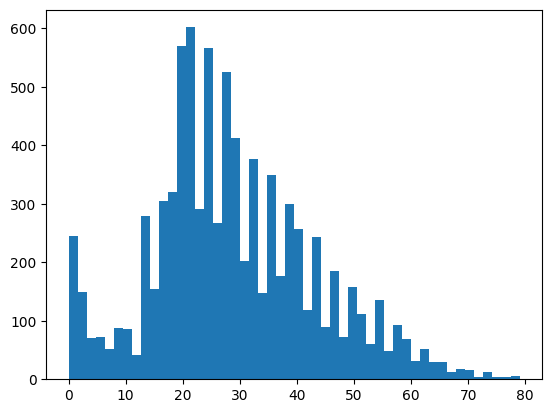

In [183]:
plt.hist(data['Age'], 50)
plt.show()

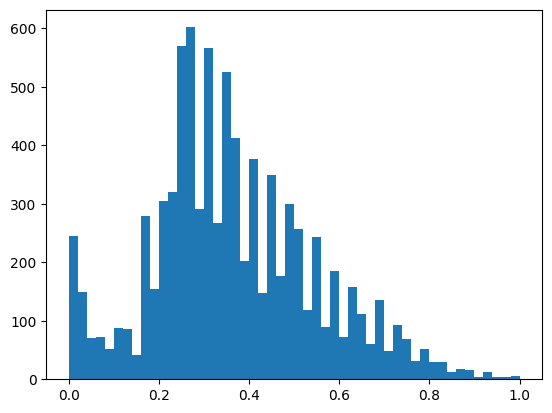

In [184]:
plt.hist(sc1_data, 50)
plt.show()

### Масштабирование данных на основе Z-оценки - StandardScaler

In [185]:
sc2 = StandardScaler()
sc2_data = sc2.fit_transform(data[['Age']])

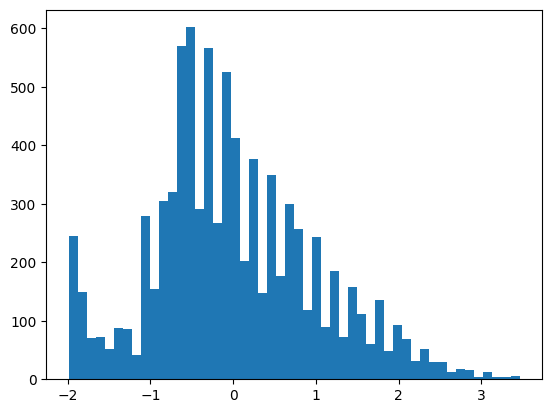

In [186]:
plt.hist(sc2_data, 50)
plt.show()